In [1]:
# Problem statement
           #predict pure gold rate based on year and 22k gold rate - Regression

# load the dataset

import pandas as pd


dataset=pd.read_csv("gold_rate_history.csv")

print(dataset.info())
print(dataset.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4971 entries, 0 to 4970
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  4971 non-null   object 
 1   Country               4971 non-null   object 
 2   State                 4971 non-null   object 
 3   Location              4971 non-null   object 
 4   Pure Gold (24 k)      4971 non-null   float64
 5   Standard Gold (22 K)  4971 non-null   float64
dtypes: float64(2), object(4)
memory usage: 233.1+ KB
None
       Date Country      State Location  Pure Gold (24 k)  \
0  1/2/2006   India  Tamilnadu  Chennai             768.0   
1  1/3/2006   India  Tamilnadu  Chennai             770.5   
2  1/4/2006   India  Tamilnadu  Chennai             784.5   
3  1/5/2006   India  Tamilnadu  Chennai             782.5   
4  1/6/2006   India  Tamilnadu  Chennai             776.0   

   Standard Gold (22 K)  
0                 711.0  
1       

In [2]:
# Data Preprocessing
       # 1. Missing values 2. duplicate entries

# 3. data type formatting

dataset.dtypes

,0
Date,object
Country,object
State,object
Location,object
Pure Gold (24 k),float64
Standard Gold (22 K),float64


In [3]:
# convert Date Col to datetime format

dataset['Date']=pd.to_datetime(dataset['Date'])



# Extract useful time features

dataset['year']=dataset['Date'].dt.year
dataset['month']=dataset['Date'].dt.month
dataset['day']=dataset['Date'].dt.day
dataset['dayofweek']=dataset['Date'].dt.dayofweek

In [ ]:
dataset

,Date,Country,State,Location,Pure Gold (24 k),Standard Gold (22 K),year,month,day,dayofweek
0,2006-01-02,India,Tamilnadu,Chennai,768.0,711.0,2006,1,2,0
1,2006-01-03,India,Tamilnadu,Chennai,770.5,713.0,2006,1,3,1
2,2006-01-04,India,Tamilnadu,Chennai,784.5,726.0,2006,1,4,2
3,2006-01-05,India,Tamilnadu,Chennai,782.5,725.0,2006,1,5,3
4,2006-01-06,India,Tamilnadu,Chennai,776.0,719.0,2006,1,6,4
...,...,...,...,...,...,...,...,...,...,...
4966,2020-10-06,India,Tamilnadu,Chennai,5103.0,4860.0,2020,10,6,1
4967,2020-10-07,India,Tamilnadu,Chennai,5046.0,4806.0,2020,10,7,2
4968,2020-10-08,India,Tamilnadu,Chennai,5051.0,4810.0,2020,10,8,3
4969,2020-10-09,India,Tamilnadu,Chennai,5093.0,4850.0,2020,10,9,4


In [4]:
# Drop unnecssary columns

dataset=dataset.drop(['Date','Country','State','Location'],axis=1)

In [5]:
dataset

,Pure Gold (24 k),Standard Gold (22 K),year,month,day,dayofweek
0,768.0,711.0,2006,1,2,0
1,770.5,713.0,2006,1,3,1
2,784.5,726.0,2006,1,4,2
3,782.5,725.0,2006,1,5,3
4,776.0,719.0,2006,1,6,4
...,...,...,...,...,...,...
4966,5103.0,4860.0,2020,10,6,1
4967,5046.0,4806.0,2020,10,7,2
4968,5051.0,4810.0,2020,10,8,3
4969,5093.0,4850.0,2020,10,9,4


In [10]:


# Define Features (X) and Target (y)
features = ['year', 'month', 'day', 'dayofweek', 'Standard Gold (22 K)']
target = 'Pure Gold (24 k)'

X = dataset[features]
y = dataset[target]


In [11]:
from sklearn.model_selection import train_test_split

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [13]:
# Predict gold prices
y_pred = rf_model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 4.04600979899498
Root Mean Squared Error (RMSE): 9.50799980656295
R² Score: 0.9999082814391832


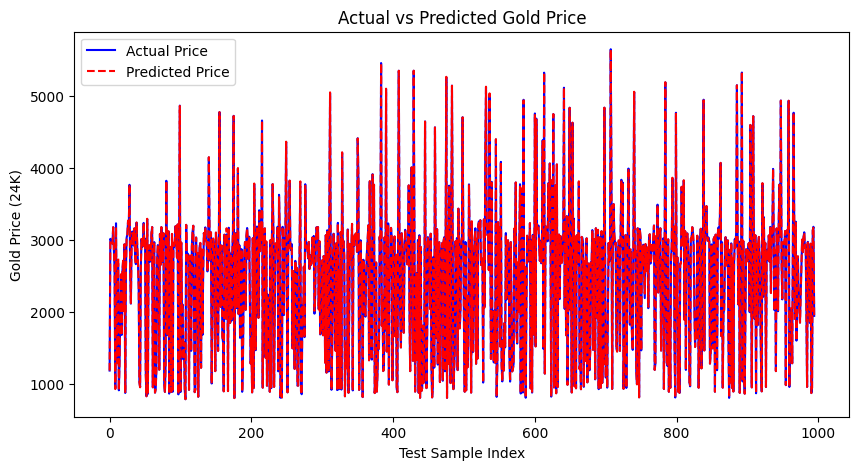

In [15]:
import matplotlib.pyplot as plt

# Plot actual vs predicted prices
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual Price", color='blue')
plt.plot(y_pred, label="Predicted Price", color='red', linestyle='dashed')
plt.xlabel("Test Sample Index")
plt.ylabel("Gold Price (24K)")
plt.title("Actual vs Predicted Gold Price")
plt.legend()
plt.show()


In [16]:
import joblib

# Save model
joblib.dump(rf_model, "gold_price_model.pkl")

# Load model (for future use)
# loaded_model = joblib.load("gold_price_model.pkl")


['gold_price_model.pkl']

In [28]:
import pandas as pd
import joblib

# 1. Create a new input (single row)
new_data = pd.DataFrame([{
    'year': 2006,
    'month': 3,
    'day': 1,
    'dayofweek': 3,  # 0=Monday, 6=Sunday
    'Standard Gold (22 K)': 713
}])


In [29]:

# 4. Load your trained model
model = joblib.load("gold_price_model.pkl")


In [30]:
# 5. Make the prediction
predicted_standard_gold = model.predict(new_data)

print("Predicted Standard Gold (22 K) Rate:", predicted_standard_gold[0])

Predicted Standard Gold (22 K) Rate: 772.505
